# Análise Exploratória — ERA5 Corrigido (IRC Vendaval), 2000-2024

Análise exploratória espacial e temporal da grade de rajada de vento máxima diária
corrigida (`artifacts/corrected_grid/final_2000_2024/`), gerada pelo pipeline
`corrected_grid` (melhor modelo por cluster × trimestre climático, treinado com
dados diários INMET 2008-2018, aplicado a toda a série ERA5 2000-2024).

**Antes de interpretar qualquer resultado aqui, leia as ressalvas conhecidas**
(seção 1.2 abaixo e `artifacts/corrected_grid/final_2000_2024/README.md`):

- Falta um gap de 7 dias (2020-01-01 a 2020-01-07) na fronteira entre as duas
  runs que geraram o dataset.
- 2000-2007 tem confiança reduzida (densidade de estações INMET muito baixa
  nesse período — o modelo treinou só com 2008-2018).
- `direcao_vento` é observação INMET bruta interpolada, **não corrigida por
  modelo**.

## Índice

1. [Carregamento e visão geral](#1)
2. [Análise espacial](#2) — climatologia média/extrema, padrão sazonal, bias, direção
3. [Análise temporal](#3) — série basin-average, ciclo sazonal, tendência anual, extremos, in/out-of-sample
4. [Séries em pontos específicos](#4)
5. [Resumo](#5)

## 1. Carregamento e visão geral <a id="1"></a>

In [1]:
from pathlib import Path

import dask
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.figsize"] = (10, 5)

DATA_DIR = Path("../artifacts/corrected_grid/final_2000_2024")
TRAIN_SLICE = ("2008-01-01", "2018-12-31")  # mesmo período de treino dos modelos
GAP_START, GAP_END = "2020-01-01", "2020-01-07"  # gap conhecido, ver README.md

In [2]:
# Carregamento LAZY (dask) — nada é lido pra memória até ser explicitamente
# computado. Evita estourar RAM ao abrir os 25 anos de uma vez (máquina local
# tem pouca RAM livre — ver notas do projeto).
files = sorted(DATA_DIR.glob("grid_corrected_*.nc"))
assert files, f"Nenhum grid_corrected_*.nc encontrado em {DATA_DIR.resolve()}"

ds = xr.open_mfdataset(
    files, combine="by_coords", chunks={"time": 90, "latitude": -1, "longitude": -1},
)
ds

/tmp/ipykernel_1379403/628825746.py:7: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 90. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(
/tmp/ipykernel_1379403/628825746.py:7: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 90. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(
/tmp/ipykernel_1379403/628825746.py:7: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 90. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(
/tmp/ipykernel_1379403/628825746.py:7: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 90. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(
/tmp/ipykern

/tmp/ipykernel_1379403/628825746.py:7: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 90. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(
/tmp/ipykernel_1379403/628825746.py:7: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 90. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(
/tmp/ipykernel_1379403/628825746.py:7: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 90. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(
/tmp/ipykernel_1379403/628825746.py:7: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 90. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(
/tmp/ipykern

<xarray.Dataset> Size: 725MB
Dimensions:               (time: 9118, latitude: 86, longitude: 77)
Coordinates:
  * time                  (time) datetime64[ns] 73kB 2000-01-08 ... 2024-12-31
    in_sample             (time) bool 9kB dask.array<chunksize=(90,), meta=np.ndarray>
  * latitude              (latitude) float64 688B -13.75 -14.0 ... -34.75 -35.0
  * longitude             (longitude) float64 616B -58.0 -57.75 ... -39.25 -39.0
Data variables:
    rajada_max_corrigida  (time, latitude, longitude) float32 242MB dask.array<chunksize=(90, 86, 77), meta=np.ndarray>
    direcao_vento         (time, latitude, longitude) float32 242MB dask.array<chunksize=(90, 86, 77), meta=np.ndarray>
    bias                  (time, latitude, longitude) float32 242MB dask.array<chunksize=(90, 86, 77), meta=np.ndarray>
Attributes:
    source:                IRC Vendaval — corrected_grid (best-model-per-clus...
    metric_used:           R2
    in_sample_period:      2008-01-01/2018-12-31
    n_stations_magnitude:  241
    n_stations_direction:  271
    idw_k:                 15
    idw_power:             2.0
    winners_csv:           winners.csv

In [3]:
print(f"Arquivos carregados: {len(files)}")
print(f"Período: {ds.time.min().values} .. {ds.time.max().values}")
print(f"Grade: {ds.sizes['latitude']} x {ds.sizes['longitude']} pontos "
      f"(lat {float(ds.latitude.min()):.2f}..{float(ds.latitude.max()):.2f}, "
      f"lon {float(ds.longitude.min()):.2f}..{float(ds.longitude.max()):.2f})")
print(f"Timesteps: {ds.sizes['time']}")
print(f"Variáveis: {list(ds.data_vars)}")

Arquivos carregados: 25
Período: 2000-01-08T00:00:00.000000000 .. 2024-12-31T00:00:00.000000000
Grade: 86 x 77 pontos (lat -35.00..-13.75, lon -58.00..-39.00)
Timesteps: 9118
Variáveis: ['rajada_max_corrigida', 'direcao_vento', 'bias']


### 1.2 Checagem de continuidade temporal (dias faltando)

Compara o range completo de dias esperado (do primeiro ao último dia do dataset)
contra os dias que realmente existem — confirma o gap conhecido de 7 dias em
jan/2020 e garante que não há nenhum outro buraco inesperado.

In [4]:
actual_dates = pd.DatetimeIndex(ds.time.values)
expected_dates = pd.date_range(actual_dates.min(), actual_dates.max(), freq="D")
missing = expected_dates.difference(actual_dates)

print(f"Dias esperados: {len(expected_dates)} | dias presentes: {len(actual_dates)} "
      f"| faltando: {len(missing)}")
if len(missing):
    # Agrupa datas faltantes consecutivas em intervalos, pra não imprimir 7 linhas soltas
    gaps = []
    start = prev = missing[0]
    for d in missing[1:]:
        if (d - prev).days > 1:
            gaps.append((start, prev))
            start = d
        prev = d
    gaps.append((start, prev))
    for a, b in gaps:
        marker = " <- gap conhecido (ver README)" if a == pd.Timestamp(GAP_START) else ""
        print(f"  {a.date()} .. {b.date()} ({(b-a).days + 1} dia(s)){marker}")
else:
    print("Nenhum gap encontrado.")

Dias esperados: 9125 | dias presentes: 9118 | faltando: 7
  2020-01-01 .. 2020-01-07 (7 dia(s)) <- gap conhecido (ver README)


## 2. Análise espacial <a id="2"></a>

Climatologia (médias/extremos ao longo do tempo, por célula de grade) — mostra
o padrão espacial da correção, não a evolução temporal.

In [5]:
def plot_map(field, title, cmap="viridis", ax=None, **kwargs):
    """Plota um campo 2D (latitude, longitude) com pcolormesh. Sem cartopy de
    propósito (evita dependência de internet pra baixar shapefile de costa,
    que pode falhar/travar offline) — os eixos lat/lon já bastam pra
    localizar o padrão espacial dentro da bacia."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))
    im = ax.pcolormesh(
        field.longitude, field.latitude, field.values, cmap=cmap, shading="auto", **kwargs,
    )
    ax.set_title(title)
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.set_aspect("equal")
    plt.colorbar(im, ax=ax, shrink=0.8)
    return ax

### 2.1 Climatologia média e extrema (2000-2024 inteiro)

/media/matteuscruz/Projects/Entrep/irc_vendaval/.venv/lib/python3.11/site-packages/dask/array/reductions.py:327: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


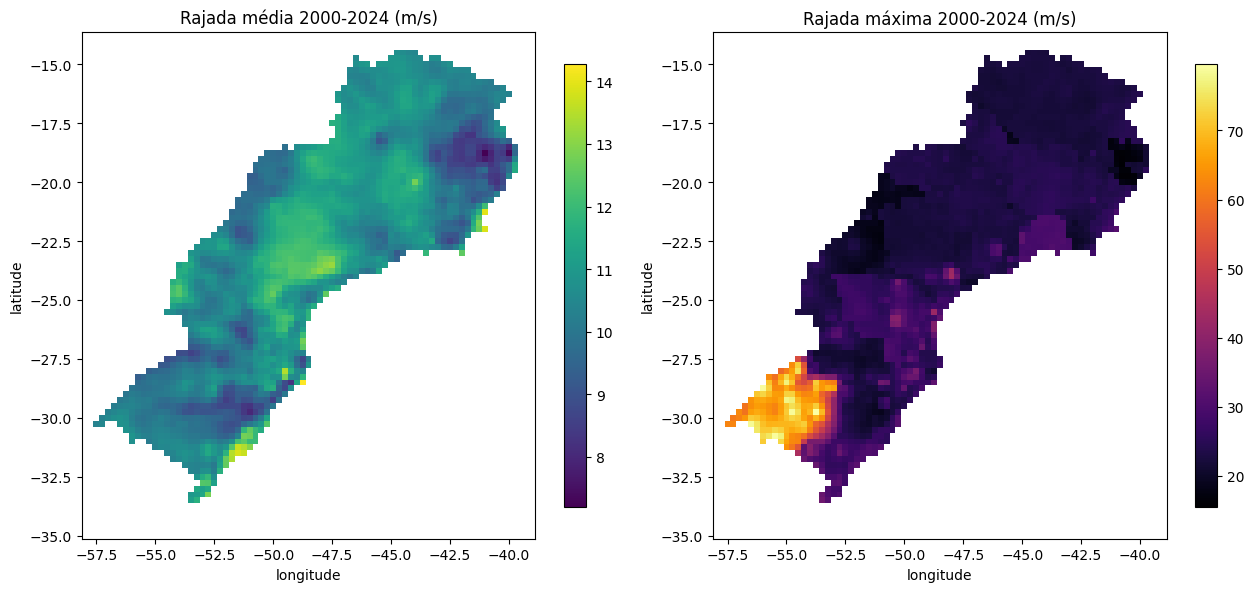

In [6]:
gust = ds["rajada_max_corrigida"]

# dask.compute(...) junto calcula os dois de uma vez só, lendo o disco uma
# única vez em vez de duas (mean + max separados reprocessariam os chunks).
gust_mean, gust_max = dask.compute(gust.mean("time"), gust.max("time"))

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
plot_map(gust_mean, "Rajada média 2000-2024 (m/s)", cmap="viridis", ax=axes[0])
plot_map(gust_max, "Rajada máxima 2000-2024 (m/s)", cmap="inferno", ax=axes[1])
plt.tight_layout()
plt.show()

### 2.2 Climatologia sazonal (DJF/MAM/JJA/SON)

Convenção hemisfério sul (DJF = verão), mesma usada no treino dos modelos —
`time.season` do xarray agrupa pelos mesmos trimestres (dez-jan-fev, etc.),
só o rótulo de estação do ano é que é do hemisfério norte por padrão; a
agrupagem em si (quais meses caem juntos) é a mesma que o projeto usa.

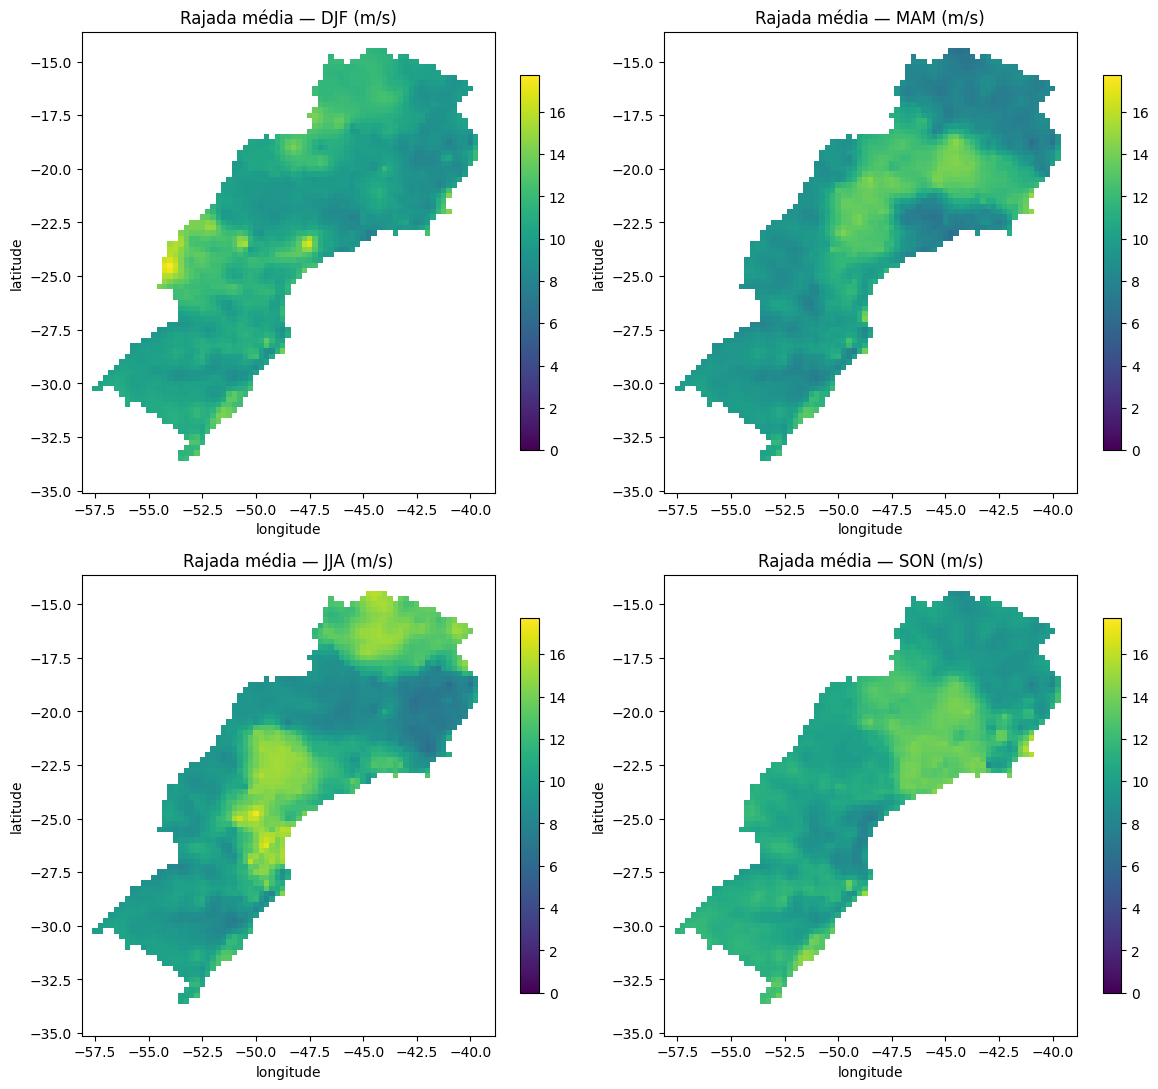

In [7]:
seasons_order = ["DJF", "MAM", "JJA", "SON"]
seasonal_mean = gust.groupby("time.season").mean("time").compute()

fig, axes = plt.subplots(2, 2, figsize=(12, 11))
vmax = float(seasonal_mean.max())
for season, ax in zip(seasons_order, axes.ravel()):
    plot_map(seasonal_mean.sel(season=season), f"Rajada média — {season} (m/s)",
              cmap="viridis", ax=ax, vmin=0, vmax=vmax)
plt.tight_layout()
plt.show()

### 2.3 Bias médio (o quanto a correção ajustou o ERA5 bruto)

`bias` = predição do modelo vencedor − proxy ERA5, interpolado (IDW) e somado de
volta ao ERA5 bruto. Valores positivos = correção aumentou a rajada em relação
ao ERA5 original; negativos = diminuiu.

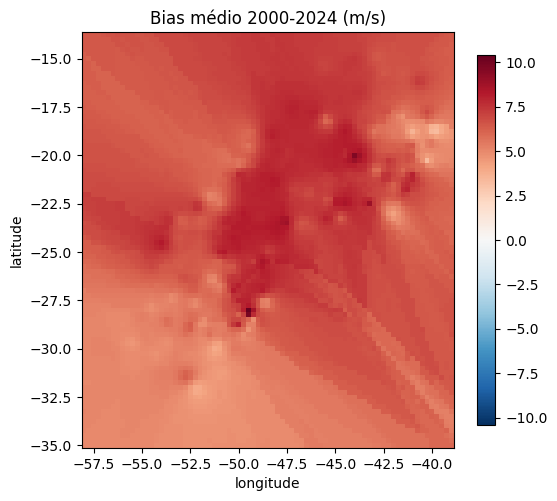

Bias médio geral (toda a grade, todo o período): 6.358 m/s


In [8]:
bias_mean = ds["bias"].mean("time").compute()
bias_abs_max = float(max(abs(bias_mean.min()), abs(bias_mean.max())))

ax = plot_map(bias_mean, "Bias médio 2000-2024 (m/s)", cmap="RdBu_r",
              vmin=-bias_abs_max, vmax=bias_abs_max)
plt.show()

print(f"Bias médio geral (toda a grade, todo o período): {float(ds['bias'].mean()):.3f} m/s")

### 2.4 Direção do vento predominante (climatologia circular)

Lembrete: `direcao_vento` é interpolação de observação INMET bruta, não passou
por nenhuma correção de modelo (ver ressalvas). A média de um ângulo não pode
ser feita direto (0° e 360° são o mesmo ponto) — decompõe em vetor unitário
(seno/cosseno), tira a média do vetor, e converte de volta pro ângulo.

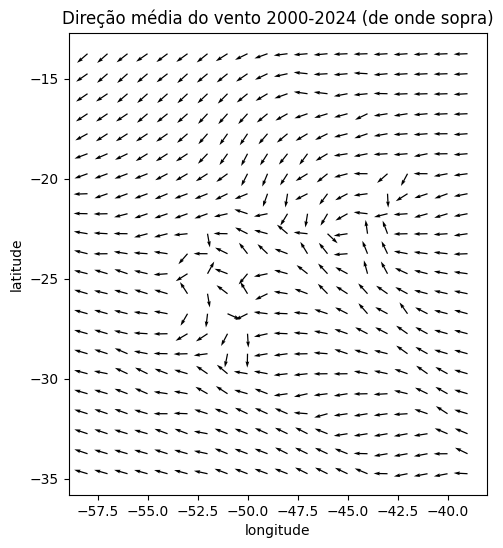

In [9]:
direction_rad = np.deg2rad(ds["direcao_vento"])
mean_sin, mean_cos = dask.compute(np.sin(direction_rad).mean("time"), np.cos(direction_rad).mean("time"))
mean_direction = (np.rad2deg(np.arctan2(mean_sin, mean_cos)) + 360) % 360

fig, ax = plt.subplots(figsize=(7, 6))
# quiver simplificado: uma seta por célula, direção = mean_direction, "de onde vem" o vento
u = -np.sin(np.deg2rad(mean_direction))
v = -np.cos(np.deg2rad(mean_direction))
step = 4  # subamostra a grade pra não poluir o plot com 86x77 setas
lon2d, lat2d = np.meshgrid(ds.longitude.values, ds.latitude.values)
ax.quiver(
    lon2d[::step, ::step], lat2d[::step, ::step],
    u.values[::step, ::step], v.values[::step, ::step],
    scale=30, width=0.003,
)
ax.set_title("Direção média do vento 2000-2024 (de onde sopra)")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.set_aspect("equal")
plt.show()

## 3. Análise temporal <a id="3"></a>

Agregações espaciais (média/máximo sobre toda a grade a cada dia) — mostra a
evolução no tempo, não o padrão espacial.

### 3.1 Série diária basin-average (2000-2024)

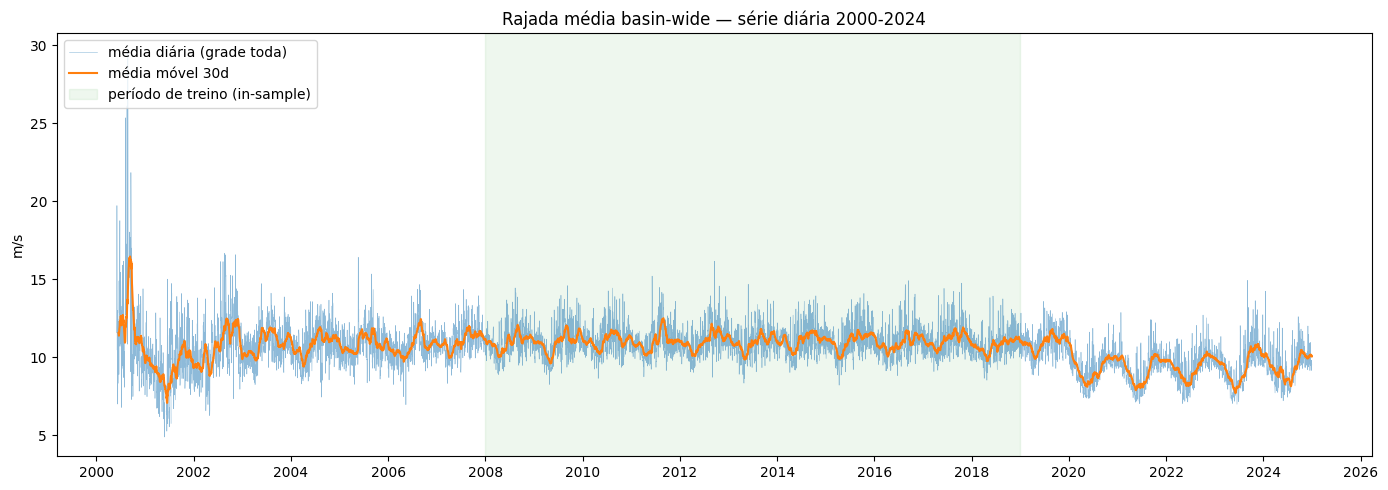

In [10]:
gust_basin_mean, gust_basin_max = dask.compute(
    gust.mean(["latitude", "longitude"]), gust.max(["latitude", "longitude"]),
)
series = pd.DataFrame({
    "mean": gust_basin_mean.to_series(),
    "max": gust_basin_max.to_series(),
})

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(series.index, series["mean"], lw=0.4, alpha=0.5, label="média diária (grade toda)")
ax.plot(series.index, series["mean"].rolling(30, min_periods=15).mean(), lw=1.5,
        label="média móvel 30d")
ax.axvspan(pd.Timestamp(TRAIN_SLICE[0]), pd.Timestamp(TRAIN_SLICE[1]),
           color="tab:green", alpha=0.08, label="período de treino (in-sample)")
ax.set_title("Rajada média basin-wide — série diária 2000-2024")
ax.set_ylabel("m/s")
ax.legend(loc="upper left")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.tight_layout()
plt.show()

### 3.2 Tendência anual (média e máximo por ano)

**Cuidado ao interpretar tendência aqui**: 2000-2007 tem confiança reduzida
(ver ressalvas no topo) — uma "tendência de queda" nos primeiros anos pode
refletir densidade de estações INMET crescendo no treino, não um sinal
climático real.

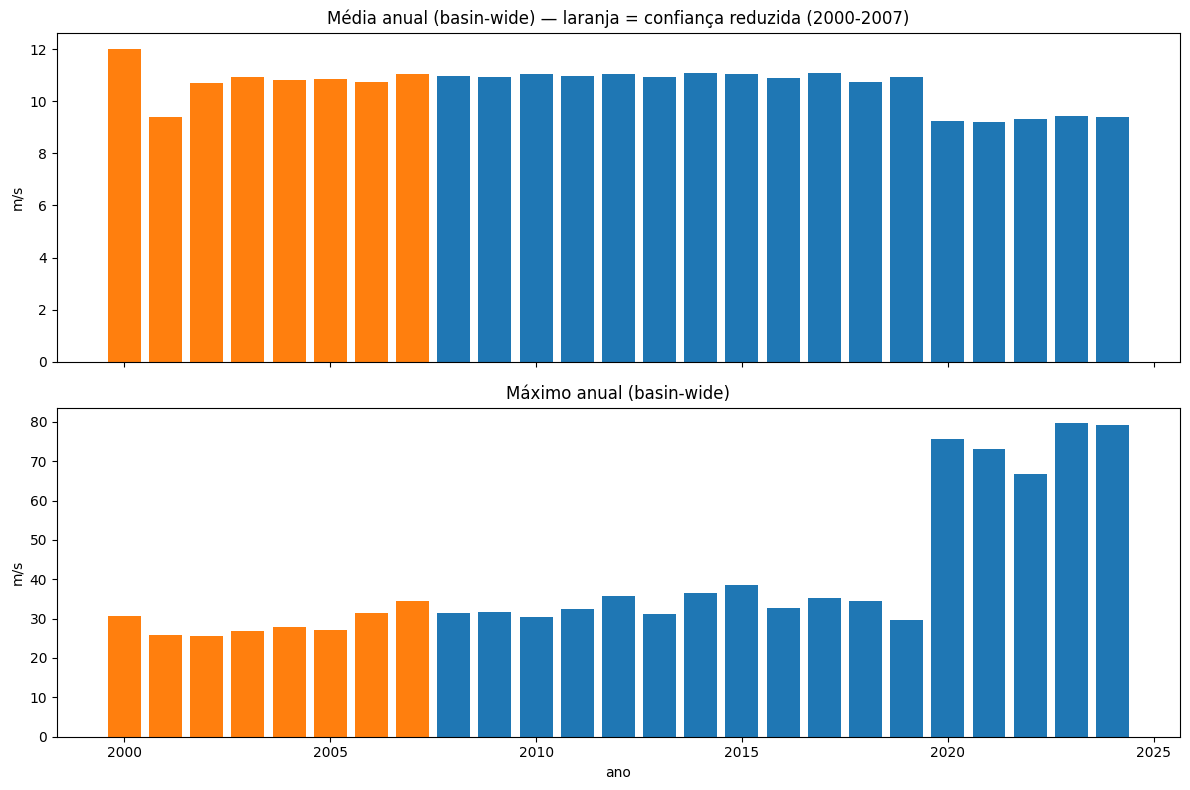

In [11]:
annual = series.groupby(series.index.year).agg(mean_annual=("mean", "mean"), max_annual=("max", "max"))

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
colors = ["tab:orange" if y < 2008 else "tab:blue" for y in annual.index]
axes[0].bar(annual.index, annual["mean_annual"], color=colors)
axes[0].set_ylabel("m/s"); axes[0].set_title("Média anual (basin-wide) — laranja = confiança reduzida (2000-2007)")
axes[1].bar(annual.index, annual["max_annual"], color=colors)
axes[1].set_ylabel("m/s"); axes[1].set_title("Máximo anual (basin-wide)")
axes[1].set_xlabel("ano")
plt.tight_layout()
plt.show()

### 3.3 Ciclo sazonal (climatologia mensal, todos os anos empilhados)

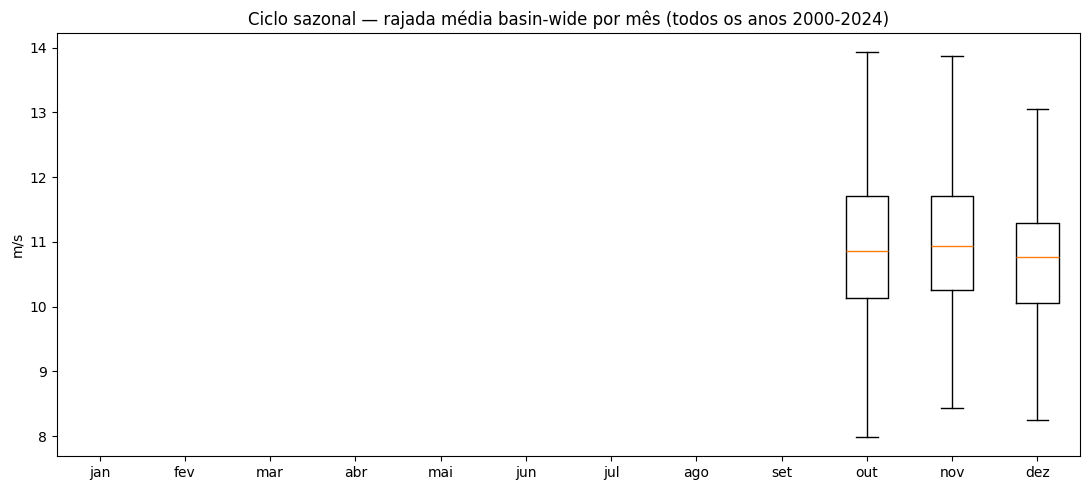

In [12]:
by_month = [series.loc[series.index.month == m, "mean"].values for m in range(1, 13)]

fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot(by_month, tick_labels=["jan","fev","mar","abr","mai","jun",
                                    "jul","ago","set","out","nov","dez"],
           showfliers=False)
ax.set_title("Ciclo sazonal — rajada média basin-wide por mês (todos os anos 2000-2024)")
ax.set_ylabel("m/s")
plt.tight_layout()
plt.show()

### 3.4 Top 20 dias com rajada mais extrema (basin-wide)

Pra cada um desses dias, localiza também a célula de grade (lat/lon) onde a
rajada máxima ocorreu — só recarrega o campo espacial dos ~20 dias
selecionados (barato), não o dataset inteiro de novo.

In [13]:
top20_dates = series["max"].nlargest(20).index

top_field = gust.sel(time=top20_dates).compute()  # só ~20 timesteps, barato

rows = []
for t in top20_dates:
    field = top_field.sel(time=t)
    idx = field.argmax(dim=["latitude", "longitude"])
    lat = float(field.latitude[idx["latitude"]])
    lon = float(field.longitude[idx["longitude"]])
    rows.append({
        "data": pd.Timestamp(t).date(),
        "rajada_max_m_s": float(field.max()),
        "lat": lat, "lon": lon,
        "in_sample": bool(ds["in_sample"].sel(time=t)),
    })

top_table = pd.DataFrame(rows).sort_values("rajada_max_m_s", ascending=False).reset_index(drop=True)
top_table

,data,rajada_max_m_s,lat,lon,in_sample
0,2023-09-04,79.606407,-29.75,-53.75,False
1,2024-01-17,79.083054,-30.75,-55.50,False
2,2023-07-12,76.870605,-28.50,-55.00,False
3,2020-02-18,75.665489,-30.25,-56.50,False
4,2024-05-02,74.516029,-28.00,-54.50,False
5,2024-05-01,74.286903,-29.75,-53.75,False
6,2023-11-16,73.908302,-28.00,-54.50,False
7,2021-01-27,72.997078,-29.75,-54.75,False
8,2020-06-30,72.896347,-28.00,-54.50,False
9,2023-10-17,72.012878,-28.50,-53.75,False


### 3.5 Distribuição: dentro vs. fora do período de treino (`in_sample`)

Compara a distribuição da rajada média diária (basin-wide) entre dias que o
modelo viu no treino (`in_sample=True`, 2008-2018) e dias de extrapolação
genuína (`in_sample=False`) — uma forma simples de checar se a correção
"explode"/diverge fora do período treinado.

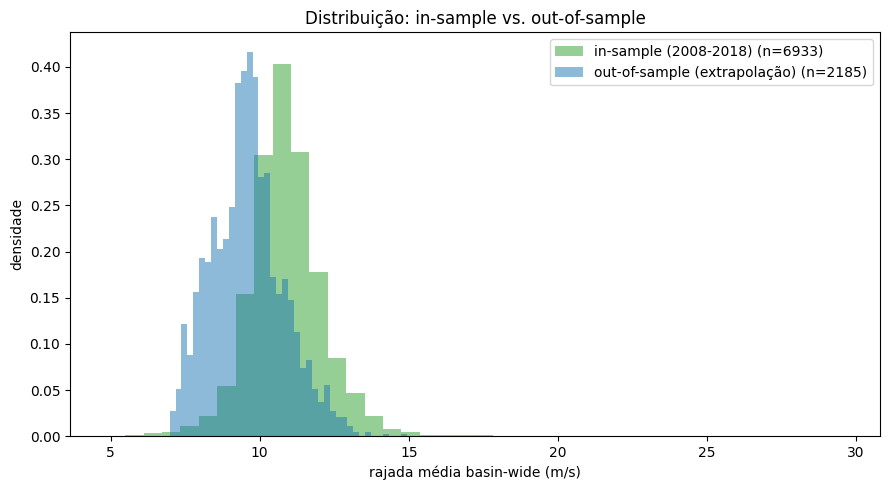

            count       mean       std       min        25%        50%  \
in_sample                                                                
False      2185.0   9.591810  1.193156  6.976086   8.757739   9.561628   
True       6761.0  10.886077  1.304110  4.871955  10.151327  10.807885   

                 75%        max  
in_sample                        
False      10.274088  14.927932  
True       11.527218  29.570942  


In [14]:
in_sample_flag = ds["in_sample"].to_series()
series["in_sample"] = in_sample_flag.reindex(series.index)

fig, ax = plt.subplots(figsize=(9, 5))
for flag, label, color in [(True, "in-sample (2008-2018)", "tab:green"),
                             (False, "out-of-sample (extrapolação)", "tab:blue")]:
    subset = series.loc[series["in_sample"] == flag, "mean"]
    ax.hist(subset, bins=40, alpha=0.5, density=True, label=f"{label} (n={len(subset)})", color=color)
ax.set_xlabel("rajada média basin-wide (m/s)")
ax.set_ylabel("densidade")
ax.set_title("Distribuição: in-sample vs. out-of-sample")
ax.legend()
plt.tight_layout()
plt.show()

print(series.groupby("in_sample")["mean"].describe())

## 4. Séries em pontos específicos <a id="4"></a>

Em vez de hardcodar coordenadas de cidades (não verificadas), escolhe 3 células
de grade programaticamente: a de maior rajada média (ponto mais "ventoso" do
domínio), a de maior variabilidade (desvio-padrão) e o centro geométrico da
grade, como referência. Ajuste `lat`/`lon` manualmente se quiser um ponto
específico (ex.: coordenada de uma usina/parque eólico).

In [15]:
gust_std = gust.std("time").compute()

idx_windiest = gust_mean.argmax(dim=["latitude", "longitude"])
idx_variable = gust_std.argmax(dim=["latitude", "longitude"])
mid_lat_idx, mid_lon_idx = ds.sizes["latitude"] // 2, ds.sizes["longitude"] // 2

points = {
    "mais ventoso (maior média)": (float(gust.latitude[idx_windiest["latitude"]]),
                                     float(gust.longitude[idx_windiest["longitude"]])),
    "mais variável (maior desvio-padrão)": (float(gust.latitude[idx_variable["latitude"]]),
                                              float(gust.longitude[idx_variable["longitude"]])),
    "centro da grade (referência)": (float(gust.latitude[mid_lat_idx]),
                                       float(gust.longitude[mid_lon_idx])),
}

point_series = {}
for label, (lat, lon) in points.items():
    point_series[label] = gust.sel(latitude=lat, longitude=lon, method="nearest").to_series()
    print(f"{label}: lat={lat:.2f}, lon={lon:.2f}")

point_df = pd.DataFrame(point_series)

/media/matteuscruz/Projects/Entrep/irc_vendaval/.venv/lib/python3.11/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


mais ventoso (maior média): lat=-28.50, lon=-48.75
mais variável (maior desvio-padrão): lat=-27.00, lon=-48.75


centro da grade (referência): lat=-24.50, lon=-48.50


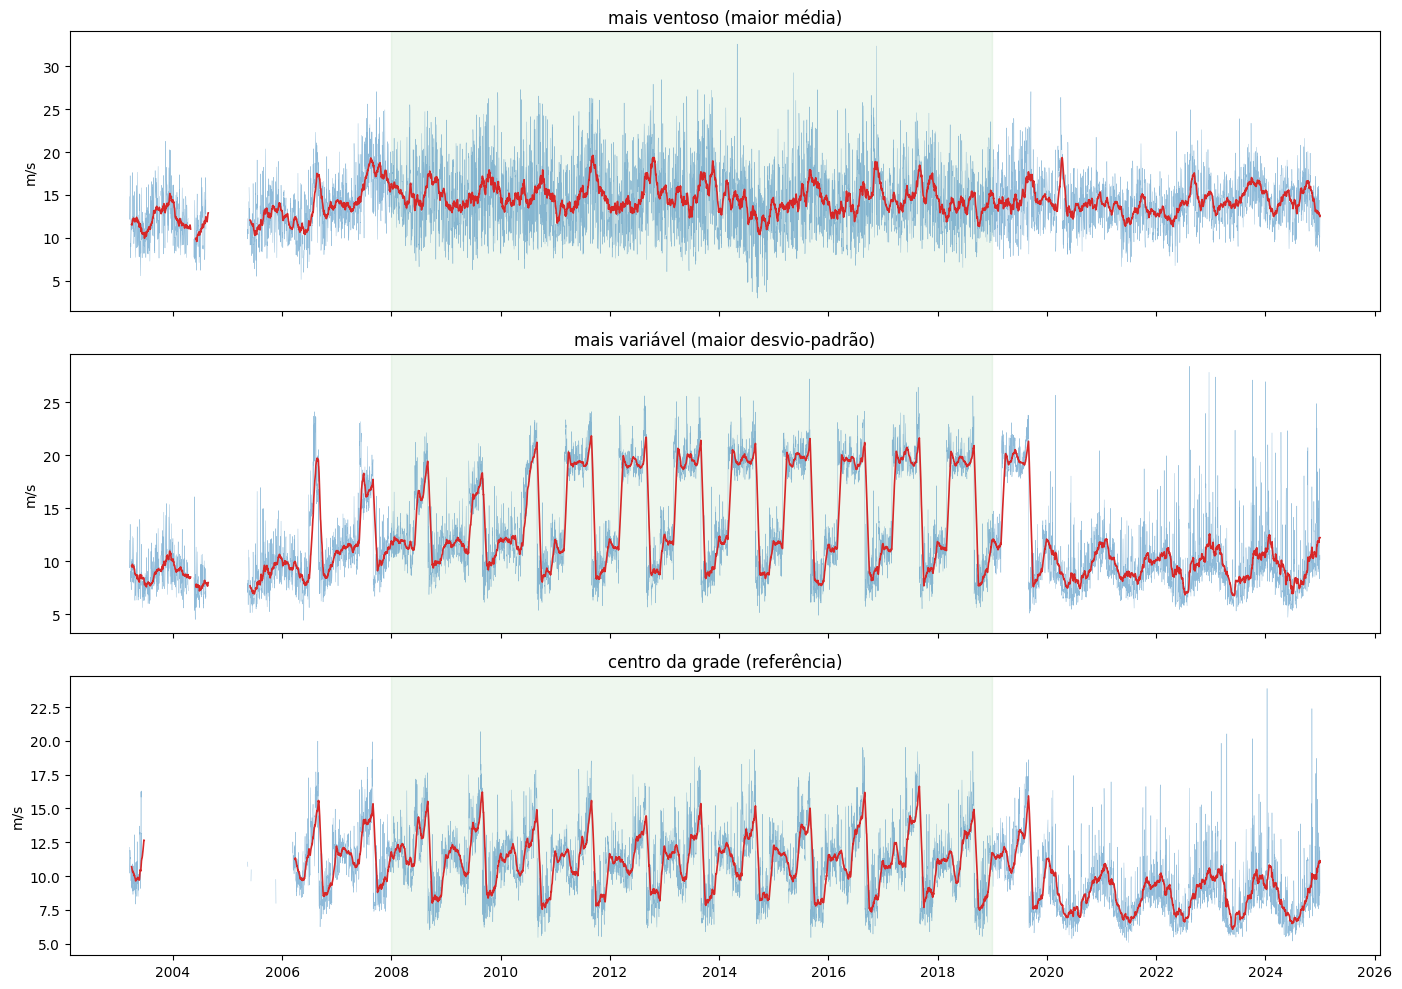

In [16]:
fig, axes = plt.subplots(len(point_df.columns), 1, figsize=(14, 10), sharex=True)
for ax, col in zip(axes, point_df.columns):
    ax.plot(point_df.index, point_df[col], lw=0.3, alpha=0.5)
    ax.plot(point_df.index, point_df[col].rolling(30, min_periods=15).mean(), lw=1.2, color="tab:red")
    ax.axvspan(pd.Timestamp(TRAIN_SLICE[0]), pd.Timestamp(TRAIN_SLICE[1]), color="tab:green", alpha=0.08)
    ax.set_title(col)
    ax.set_ylabel("m/s")
axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
plt.tight_layout()
plt.show()

## 5. Resumo <a id="5"></a>

- Dataset cobre 2000-2024 (25 anos), grade 0.25° / 86×77 pontos, Sul/Sudeste do Brasil.
- Gap conhecido: 7 dias (2020-01-01 a 2020-01-07) — confirmado na seção 1.2.
- 2000-2007: confiança reduzida (baixa densidade de estações INMET no treino) — tratar tendências desse trecho com cautela (seção 3.2).
- Distribuição in-sample vs. out-of-sample (seção 3.5) é o principal sinal de "a correção generaliza razoavelmente fora do período de treino?" — sem essa comparação, qualquer extrapolação é uma caixa-preta.
- Próximos passos sugeridos: validar os pontos/dias extremos da seção 3.4 contra registros conhecidos de eventos de vento severo na região (se existirem), e repetir esta análise separando por cluster espacial (`dataset/shp/shp_vento.shp`) se for necessário granularidade sub-bacia.

Ver também `artifacts/corrected_grid/final_2000_2024/README.md` (dicionário de dados completo) e `winners_full.csv` (qual modelo/pipeline venceu em cada cluster × trimestre).